# Supplier Analysis

Score suppliers on cost, lead time, quality, and on-time delivery, then allocate procurement quantities subject to MOQ and capacity.

In [3]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
supplier_scores = pd.read_csv(PROJECT_ROOT / "data/processed/supplier_scores.csv")
display(supplier_scores.sort_values(["raw_material_id", "supplier_rank"]))
top_suppliers = supplier_scores[supplier_scores["supplier_rank"] == 1]
display(top_suppliers)

,supplier_id,supplier_name,raw_material_id,unit_cost,lead_time_days,moq,supplier_capacity,quality_rate,on_time_rate,cost_score,lead_time_score,quality_score,on_time_score,supplier_score,supplier_rank
0,S001,Bharat Sugar Mills,RM001,0.62,7,500,100000,0.985,0.960,0.666667,0.700000,0.681818,0.714286,0.688268,1.0
1,S003,Prime Sugar Co,RM001,0.70,4,500,80000,0.992,0.980,0.000000,1.000000,1.000000,1.000000,0.650000,2.0
2,S002,National Sweeteners,RM001,0.58,14,2000,150000,0.970,0.910,1.000000,0.000000,0.000000,0.000000,0.350000,3.0
3,S006,Premium Flavors,RM002,4.60,7,100,8000,0.998,0.985,0.000000,1.000000,1.000000,1.000000,0.650000,1.0
4,S004,FlavorChem India,RM002,4.30,14,100,12000,0.990,0.950,0.600000,0.500000,0.652174,0.461538,0.555819,2.0
5,S005,Beverage Ingredients Ltd,RM002,4.10,21,250,18000,0.975,0.920,1.000000,0.000000,0.000000,0.000000,0.350000,3.0
6,S007,GasTech,RM003,1.65,5,100,5000,0.995,0.970,0.000000,1.000000,1.000000,1.000000,0.650000,1.0
7,S008,Industrial Gases India,RM003,1.55,10,250,7000,0.990,0.940,1.000000,0.000000,0.000000,0.000000,0.350000,2.0
8,S011,FastBottle,RM004,2.15,6,5000,300000,0.995,0.980,0.000000,1.000000,1.000000,1.000000,0.650000,1.0
9,S009,PackBottle India,RM004,2.00,10,5000,500000,0.985,0.950,0.600000,0.666667,0.500000,0.625000,0.599583,2.0


,supplier_id,supplier_name,raw_material_id,unit_cost,lead_time_days,moq,supplier_capacity,quality_rate,on_time_rate,cost_score,lead_time_score,quality_score,on_time_score,supplier_score,supplier_rank
0,S001,Bharat Sugar Mills,RM001,0.62,7,500,100000,0.985,0.960,0.666667,0.7,0.681818,0.714286,0.688268,1.0
3,S006,Premium Flavors,RM002,4.60,7,100,8000,0.998,0.985,0.000000,1.0,1.000000,1.000000,0.650000,1.0
6,S007,GasTech,RM003,1.65,5,100,5000,0.995,0.970,0.000000,1.0,1.000000,1.000000,0.650000,1.0
8,S011,FastBottle,RM004,2.15,6,5000,300000,0.995,0.980,0.000000,1.0,1.000000,1.000000,0.650000,1.0
11,S014,QuickCaps,RM005,0.36,5,5000,300000,0.997,0.985,0.000000,1.0,1.000000,1.000000,0.650000,1.0
14,S015,LabelWorks,RM006,0.11,7,10000,500000,0.990,0.970,0.666667,0.7,0.555556,0.769231,0.676752,1.0
17,S020,QuickCarton,RM007,8.60,4,500,30000,0.995,0.985,0.000000,1.0,1.000000,1.000000,0.650000,1.0
20,S023,FastFilm,RM008,2.20,4,100,10000,0.998,0.985,0.000000,1.0,1.000000,1.000000,0.650000,1.0


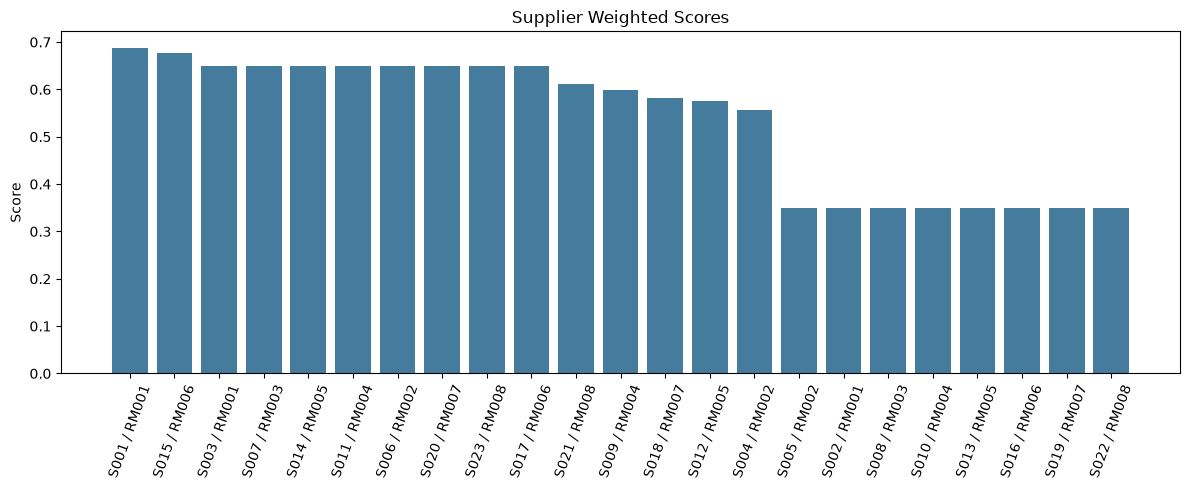

In [5]:
score_plot = supplier_scores.sort_values("supplier_score", ascending=False)
plt.figure(figsize=(12, 5))
labels = score_plot["supplier_id"] + " / " + score_plot["raw_material_id"]
plt.bar(labels, score_plot["supplier_score"], color="#457b9d")
plt.title("Supplier Weighted Scores")
plt.ylabel("Score")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

In [7]:
supplier_plan = pd.read_csv(PROJECT_ROOT / "data/processed/supplier_purchase_plan.csv", parse_dates=["week_start"])
display(supplier_plan.head(20))

,week_start,plant_id,raw_material_id,required_quantity,supplier_id,supplier_name,unit_cost,lead_time_days,supplier_score,purchase_quantity,purchase_cost
0,2025-07-07,P01,RM001,6500.0,S001,Bharat Sugar Mills,0.62,7,0.688268,6500,4030.0
1,2025-07-14,P01,RM001,9500.0,S001,Bharat Sugar Mills,0.62,7,0.688268,9500,5890.0
2,2025-07-21,P01,RM001,10000.0,S001,Bharat Sugar Mills,0.62,7,0.688268,10000,6200.0
3,2025-07-28,P01,RM001,9000.0,S001,Bharat Sugar Mills,0.62,7,0.688268,9000,5580.0
4,2025-08-04,P01,RM001,8500.0,S001,Bharat Sugar Mills,0.62,7,0.688268,8500,5270.0
5,2025-08-11,P01,RM001,9000.0,S001,Bharat Sugar Mills,0.62,7,0.688268,9000,5580.0
6,2025-08-18,P01,RM001,8500.0,S001,Bharat Sugar Mills,0.62,7,0.688268,8500,5270.0
7,2025-08-25,P01,RM001,9000.0,S001,Bharat Sugar Mills,0.62,7,0.688268,9000,5580.0
8,2025-09-01,P01,RM001,8500.0,S001,Bharat Sugar Mills,0.62,7,0.688268,8500,5270.0
9,2025-09-08,P01,RM001,8500.0,S001,Bharat Sugar Mills,0.62,7,0.688268,8500,5270.0


,supplier_id,supplier_name,purchase_quantity,purchase_cost
3,S011,FastBottle,8000000,17200000.0
6,S020,QuickCarton,447500,3848500.0
4,S014,QuickCaps,8000000,2880000.0
1,S006,Premium Flavors,242200,1114120.0
5,S015,LabelWorks,8010000,881100.0
0,S001,Bharat Sugar Mills,1193500,739970.0
7,S023,FastFilm,47300,104060.0
2,S007,GasTech,10700,17655.0


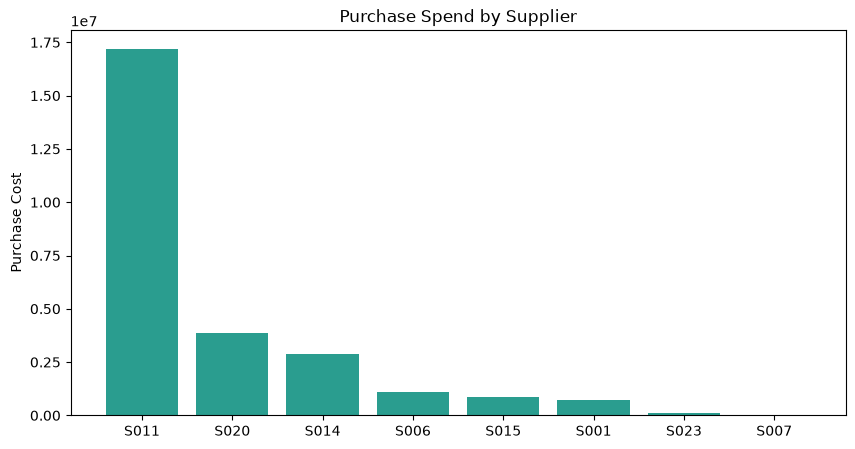

In [8]:
supplier_spend = supplier_plan.groupby(["supplier_id", "supplier_name"], as_index=False).agg(purchase_quantity=("purchase_quantity", "sum"), purchase_cost=("purchase_cost", "sum")).sort_values("purchase_cost", ascending=False)
display(supplier_spend)
plt.figure(figsize=(10, 5))
plt.bar(supplier_spend["supplier_id"], supplier_spend["purchase_cost"], color="#2a9d8f")
plt.title("Purchase Spend by Supplier")
plt.ylabel("Purchase Cost")
plt.show()